In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data= pd.read_csv('ab_test_data.csv')
data.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     19998 non-null  str  
 1   timestamp   19998 non-null  str  
 2   test_group  19998 non-null  str  
 3   conversion  19998 non-null  int64
dtypes: int64(1), str(3)
memory usage: 625.1 KB


In [4]:
data['timestamp'] = pd.to_datetime(data['timestamp'])

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     19998 non-null  str           
 1   timestamp   19998 non-null  datetime64[us]
 2   test_group  19998 non-null  str           
 3   conversion  19998 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 625.1 KB


In [6]:
# Кількість користувачів у групах

group_A_users = data[data['test_group'] == 'a']['user_id'].nunique()
group_B_users = data[data['test_group'] == 'b']['user_id'].nunique()

print("Users in group A:", group_A_users)
print("Users in group B:", group_B_users)

Users in group A: 10013
Users in group B: 9985


In [7]:
# Кількість конверсій у групах

conv_A = data[data['test_group'] == 'a']['conversion'].sum()
conv_B = data[data['test_group'] == 'b']['conversion'].sum()

print("Conversions A:", conv_A)
print("Conversions B:", conv_B)

Conversions A: 611
Conversions B: 889


In [8]:
# Рівень конверсії

cr_A = conv_A / group_A_users
cr_B = conv_B / group_B_users

print("Conversion rate A:", cr_A)
print("Conversion rate B:", cr_B)

Conversion rate A: 0.06102067312493758
Conversion rate B: 0.08903355032548824


In [9]:
# Початок, кінець та тривалість тесту

start_date = data['timestamp'].min()
end_date = data['timestamp'].max()

duration = (end_date - start_date).days

print("Start date:", start_date)
print("End date:", end_date)
print("Duration (days):", duration)

Start date: 2023-07-03 01:42:34.033708
End date: 2023-07-25 01:41:19.152664
Duration (days): 21


In [10]:
# Створюємо таблицю для χ² тесту

from scipy import stats
table = np.array([
    [conv_A, group_A_users - conv_A],
    [conv_B, group_B_users - conv_B]
])

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p_value)

Chi2: 56.14249485320227
p-value: 6.740440730497395e-14


In [11]:
# Гіпотези:
# H0: конверсія в групах однакова
# H1: конверсії відрізняються

alpha = 0.05

if p_value < alpha:
    print("Reject H0 — різниця статистично значуща")
else:
    print("Fail to reject H0 — статистично значущої різниці немає")

Reject H0 — різниця статистично значуща


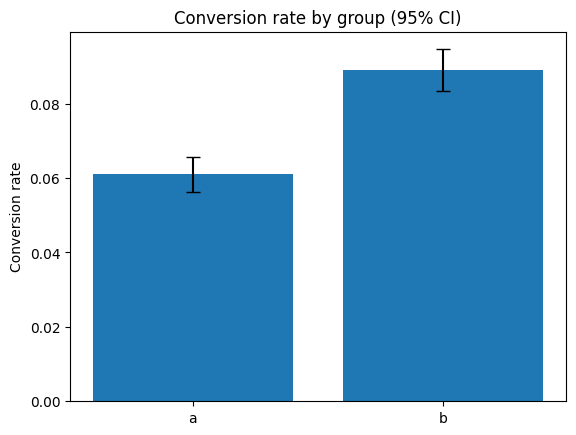

In [12]:
# Візуалізація середніх з 95% CI

import matplotlib.pyplot as plt

group_stats = data.groupby('test_group')['conversion'].agg(['mean','count','std'])

means = group_stats['mean']
counts = group_stats['count']
stds = group_stats['std']

# стандартна помилка
se = stds / np.sqrt(counts)

# 95% CI
ci = se * stats.t.ppf((1 + 0.95) / 2., counts-1)

plt.bar(means.index, means, yerr=ci, capsize=5)
plt.ylabel('Conversion rate')
plt.title('Conversion rate by group (95% CI)')
plt.savefig('ab_test_chart.png', bbox_inches='tight', dpi=300) # Для збереження графіка в .png
plt.show()

In [13]:
# Висновки:
# У A/B-тестуванні взяли участь 19 998 користувачів, розділених на групи A та B.
# Для перевірки статистичної значущості різниці в коефіцієнтах конверсії було використано chi-square test.
# Коефіцієнт конверсії в групі B був вищим, ніж у групі A.
# Різниця статистично значуща
# Отже, повідомлення про знижку суттєво впливає на коефіцієнт конверсії.


In [14]:
# Зміна конверсії в часі
data['date'] = data['timestamp'].dt.date # Спочатку створимо колонку дата.
daily_conversion = data.groupby(['date','test_group'])['conversion'].mean().reset_index() #Рахуємо конверсію по днях

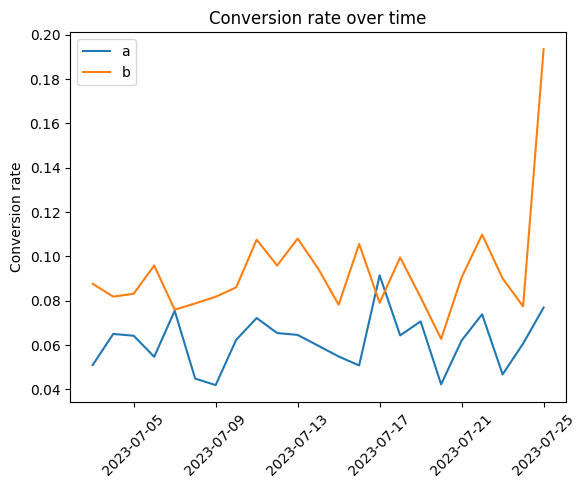

In [15]:
# Побудова графіка
import matplotlib.pyplot as plt

for group in daily_conversion['test_group'].unique():
    subset = daily_conversion[daily_conversion['test_group']==group]
    plt.plot(subset['date'], subset['conversion'], label=group)

plt.legend()
plt.xticks(rotation=45)
plt.ylabel('Conversion rate')
plt.title('Conversion rate over time')
plt.show()